send finns: True
rec finns : True

Vald elektrisk modell: Bohus
R20_total = 1.257525 Ω
alpha = 0.00403 1/K


C:\Users\lundi\AppData\Local\Temp\ipykernel_18072\1294369430.py:93: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_18072\1294369430.py:93: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Synkat dataset:
rows: 7669
start: 2025-12-11 15:25:02.469999
slut : 2025-12-11 15:27:32.450000
fs = 50.00250012500625 Hz

Antagna termiska parametrar:
T_amb = 15.0 °C
T_max = 70.0 °C
I_rated = 1009.0 A
lambda_sheath = 0.100
R_th = 0.00003250 K/W per fas
tau = 5400.0 s


,Phase,Model,R20_total_Ohm,R_th_K_per_W,tau_s,I_eff_mean_A,P_cond_mean_W,R_cond_mean_Ohm,T_cond_mean_C,T_cond_max_C,P_send_mean_W,P_rec_mean_W
0,L1,Bohus,1.257525,0.000033,5400.0,190.470224,49247.746471,1.232303,15.023036,15.043898,1.546604e+07,1.524867e+07
1,L2,Bohus,1.257525,0.000033,5400.0,200.893290,54779.406474,1.232316,15.025636,15.048834,1.627749e+07,1.605842e+07
2,L3,Bohus,1.257525,0.000033,5400.0,191.736298,49901.330343,1.232304,15.023356,15.044483,1.551126e+07,1.527066e+07



Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\bohus_cable_thermal_model


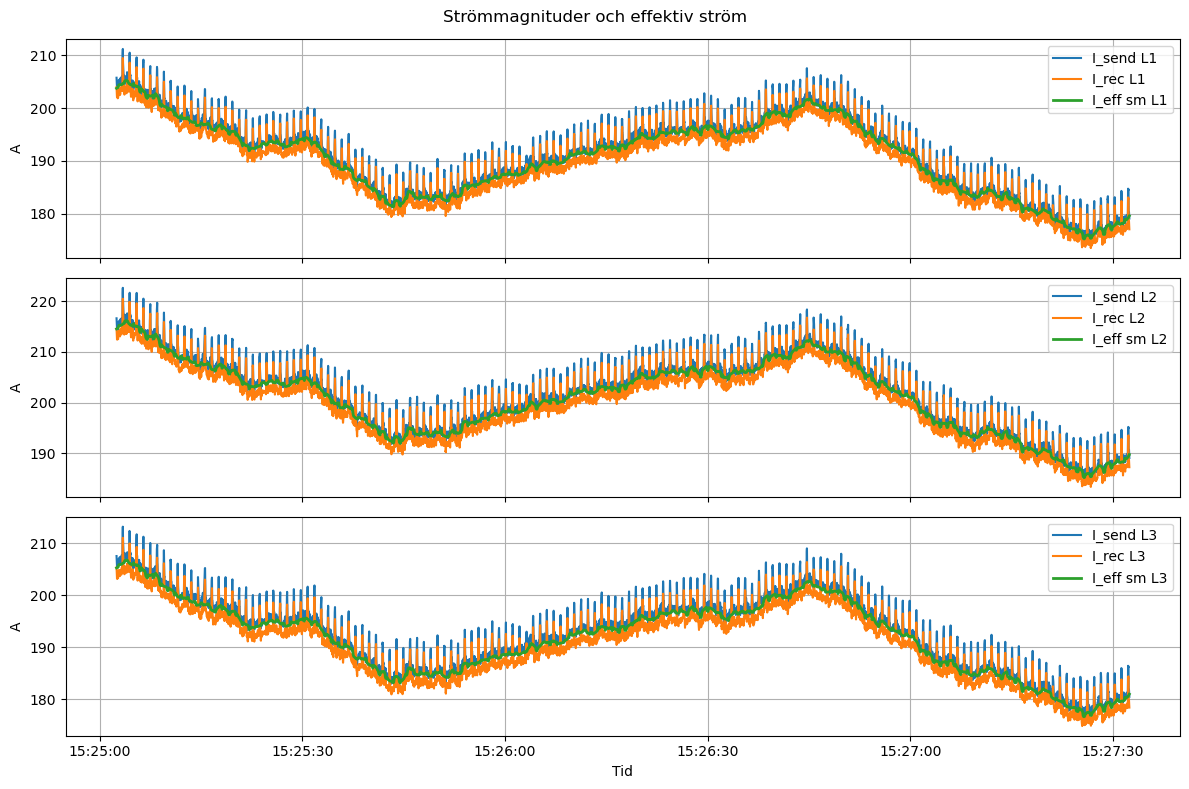

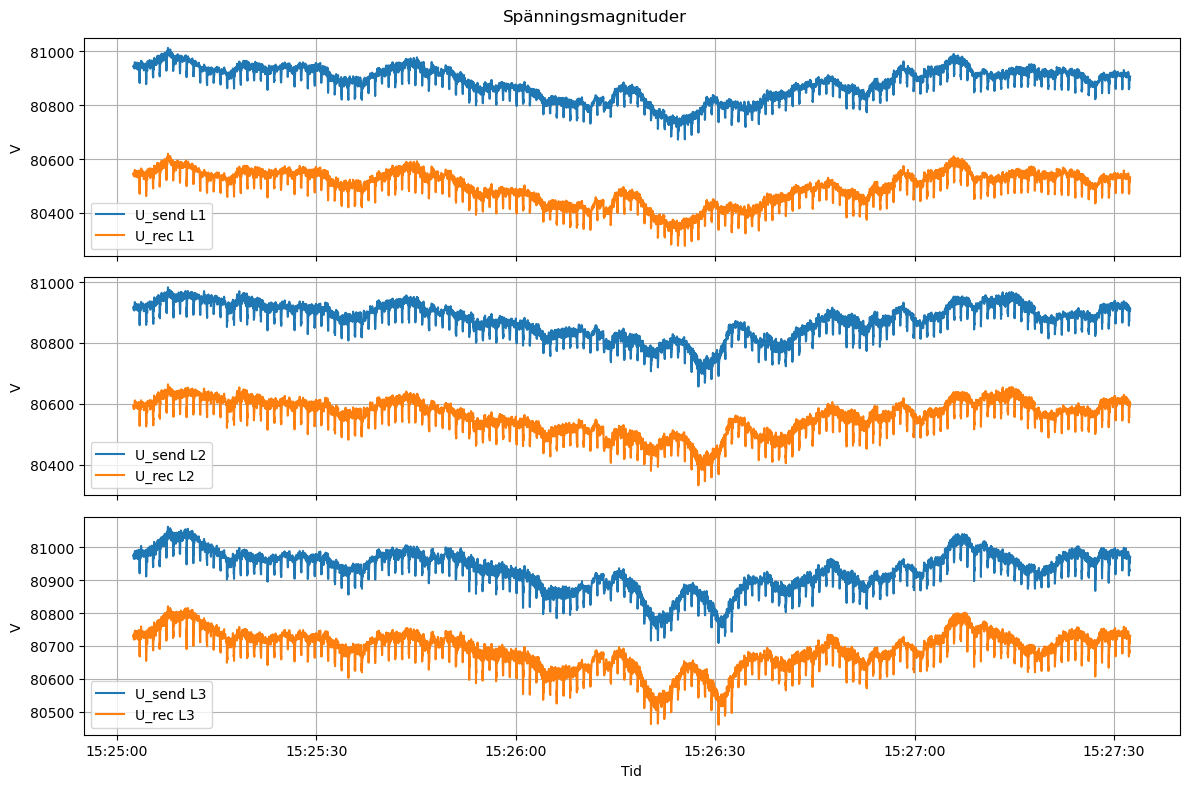

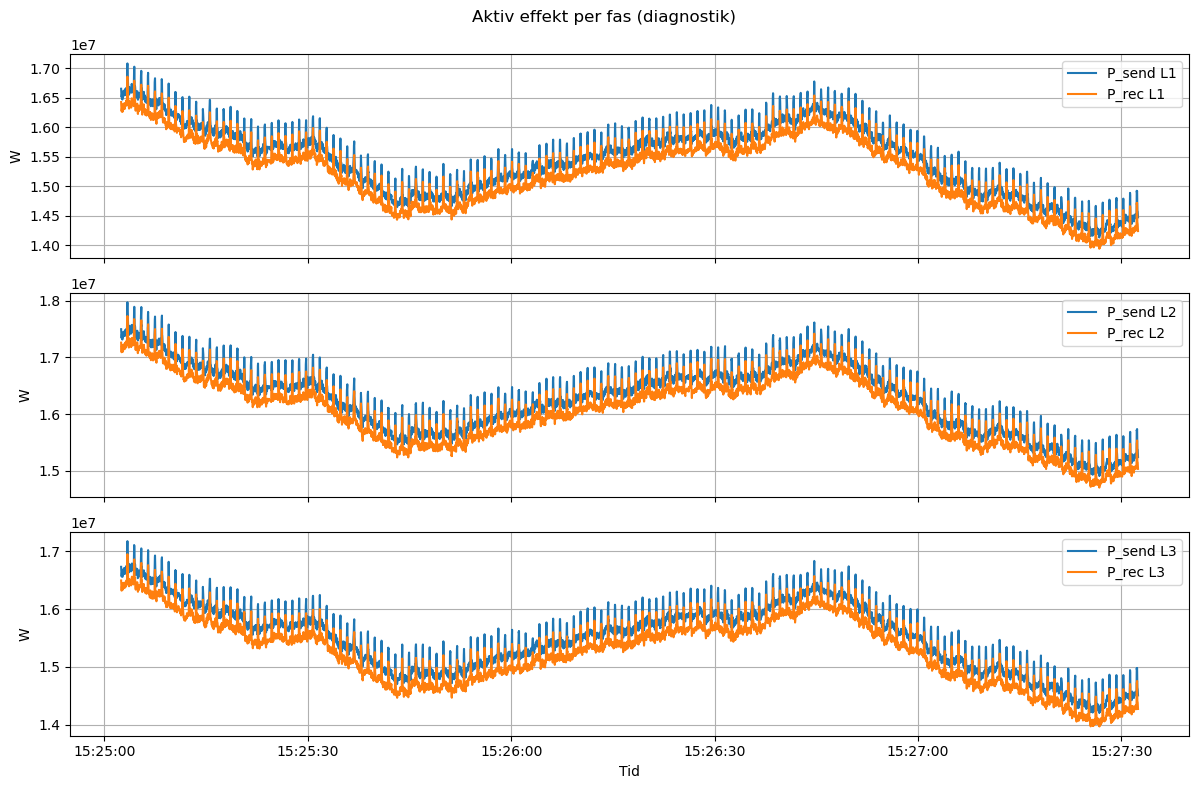

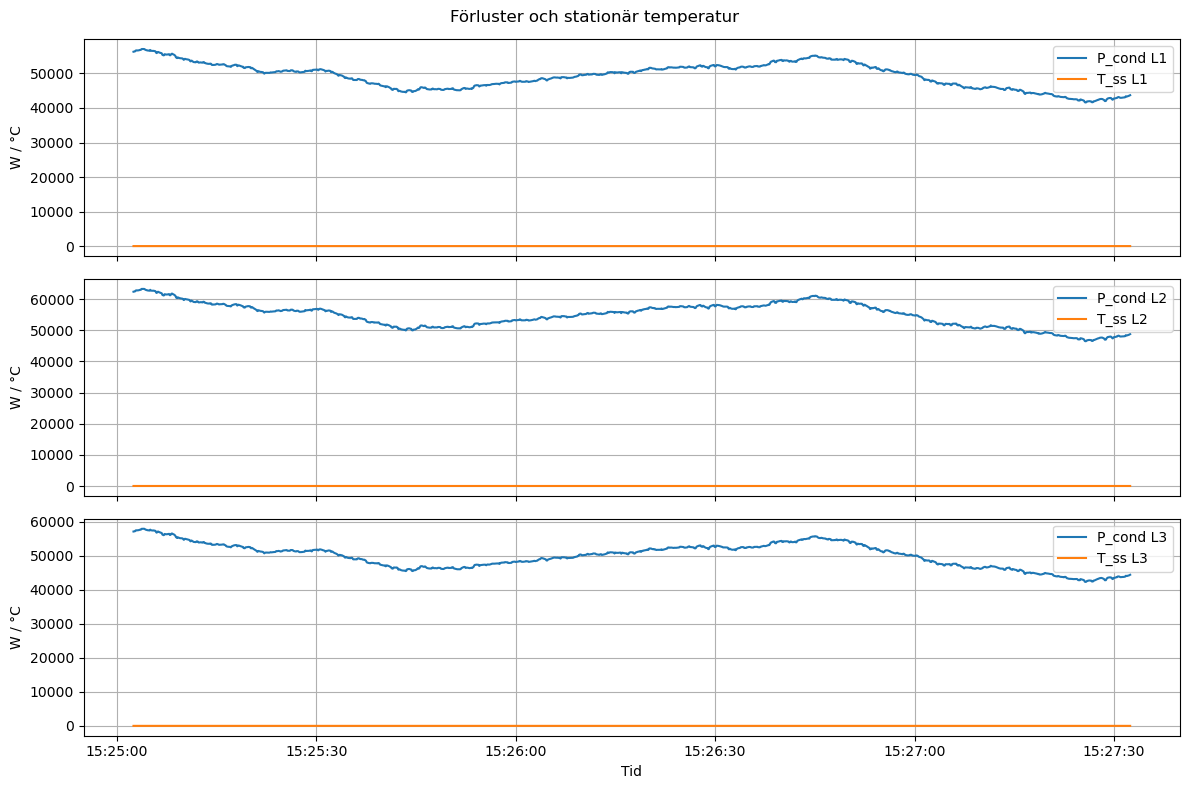

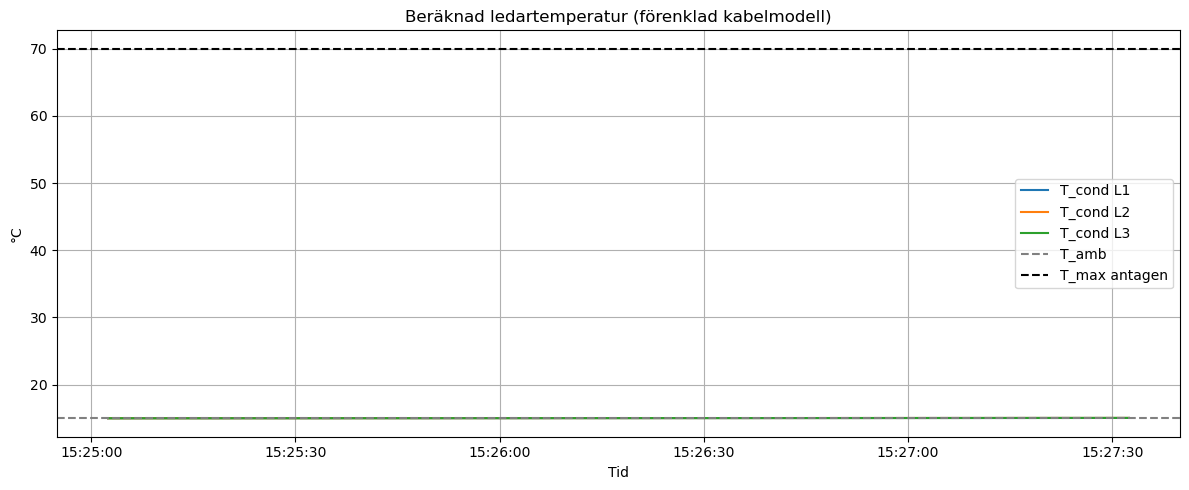

In [1]:
# ============================================================
# KABELMODELL (FÖRENKLAD) FRÅN SAMMA PMU-DATA
# send/rec -> I_eff -> I²R-förluster -> termisk modell -> T
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# VÄLJ ELEKTRISK BASMODELL (från Olsson)
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
    },
}

model = MODELS[MODEL]
R20_total = model["RAC_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]

print(f"\nVald elektrisk modell: {MODEL}")
print(f"R20_total = {R20_total:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")

# ============================================================
# ANTAGNA KABELPARAMETRAR (JUSTERBARA)
# ============================================================
# Det här är antaganden för att "låtsas att detta är en kabel"

T_amb_C = 15.0            # antagen mark/omgivningstemperatur
T_max_C = 70.0            # antagen max kontinuerlig ledartemperatur
I_rated_A = 1009.0        # antagen märkström (Bohus-lik utgångspunkt)
tau_minutes = 90.0        # antagen termisk tidskonstant för kabel
lambda_sheath = 0.10      # enkel skärm-/mantelförlustfaktor (10%)
P_diel_per_phase_W = 0.0  # dielektriska förluster, sätt 0 om okända

# Om du vill testa större/lägre känslighet, ändra dessa tre:
# T_amb_C, I_rated_A, tau_minutes

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_real_mean(x, window):
    return pd.Series(x, index=x.index).rolling(window=window, center=True, min_periods=1).mean()

# ============================================================
# 1. LÄS OCH BYGG SYNKAT DATASET
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()

# filtrera bort orimliga vinkelvärden
angle_cols = [c for c in df_joined.columns if "ANG" in c]
for c in angle_cols:
    df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

print("\nSynkat dataset:")
print("rows:", len(df_joined))
print("start:", df_joined.index.min())
print("slut :", df_joined.index.max())

# ============================================================
# 2. SAMPLINGSFREKVENS
# ============================================================

dt_series = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt_series.median()
print("fs =", fs, "Hz")

# för plottar kan vi göra ett litet glidande medelvärde på strömmen
smooth_seconds = 1.0
smooth_window = int(round(smooth_seconds * fs))

# ============================================================
# 3. KALIBRERA TERMISK RESISTANS FRÅN ANTAGEN RATINGPUNKT
# ============================================================

# Resistans vid max temperatur
R_at_Tmax = R20_total * (1 + alpha * (T_max_C - 20.0))

# Antagen total förlust per fas vid märkström
P_rated_per_phase = (I_rated_A ** 2) * R_at_Tmax * (1 + lambda_sheath) + P_diel_per_phase_W

# Termisk resistans per fas [K/W]
R_th = (T_max_C - T_amb_C) / P_rated_per_phase

# Termisk tidskonstant [s]
tau_s = tau_minutes * 60.0

print("\nAntagna termiska parametrar:")
print(f"T_amb = {T_amb_C:.1f} °C")
print(f"T_max = {T_max_C:.1f} °C")
print(f"I_rated = {I_rated_A:.1f} A")
print(f"lambda_sheath = {lambda_sheath:.3f}")
print(f"R_th = {R_th:.8f} K/W per fas")
print(f"tau = {tau_s:.1f} s")

# ============================================================
# 4. BERÄKNA KABELTEMPERATUR PER FAS
# ============================================================

out = pd.DataFrame(index=df_joined.index)
summary_rows = []

for ph in ["L1", "L2", "L3"]:
    U_mag_S = df_joined[f"U{ph}MAG_S"]
    U_mag_R = df_joined[f"U{ph}MAG_R"]

    I_mag_S = df_joined[f"I{ph}MAG_S"]
    I_mag_R = df_joined[f"I{ph}MAG_R"]

    U_ang_S = df_joined[f"U{ph}ANG_S"]
    U_ang_R = df_joined[f"U{ph}ANG_R"]

    I_ang_S = df_joined[f"I{ph}ANG_S"]
    I_ang_R = df_joined[f"I{ph}ANG_R"]

    # korrigerad mottagarström: 180° för konsekvent riktning
    I_ang_R_corr = wrap_angle_deg(I_ang_R + 180.0)

    # aktiv effekt som referens/diagnostik
    Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
    Vr = complex_from_mag_ang(U_mag_R, U_ang_R)

    Is = complex_from_mag_ang(I_mag_S, I_ang_S)
    Ir = complex_from_mag_ang(I_mag_R, I_ang_R_corr)   # redan korrigerad i vinkel

    P_send = np.real(Vs * np.conj(Is))
    P_rec  = np.real(Vr * np.conj(Ir))

    # effektiv ström från båda ändar
    I_eff = np.sqrt((I_mag_S**2 + I_mag_R**2) / 2.0)
    I_eff_sm = rolling_real_mean(I_eff, smooth_window)

    # dynamisk temperaturmodell
    T = np.zeros(len(df_joined))
    R_cond = np.zeros(len(df_joined))
    P_cond = np.zeros(len(df_joined))
    T_ss = np.zeros(len(df_joined))

    # startvärde
    T[0] = T_amb_C

    idx = df_joined.index.to_list()

    for k in range(len(df_joined)):
        if k > 0:
            dt = (idx[k] - idx[k-1]).total_seconds()
        else:
            dt = dt_series.median()

        # temperaturberoende resistans
        R_cond[k] = R20_total * (1 + alpha * (T[max(k-1, 0)] - 20.0))

        # elektriska förluster per fas
        P_cond[k] = (I_eff_sm.iloc[k] ** 2) * R_cond[k] * (1 + lambda_sheath) + P_diel_per_phase_W

        # stationärt temperaturmål
        T_ss[k] = T_amb_C + P_cond[k] * R_th

        if k > 0:
            a = 1.0 - np.exp(-dt / tau_s)
            T[k] = T[k-1] + a * (T_ss[k] - T[k-1])

    out[f"I_eff_{ph}"] = I_eff
    out[f"I_eff_sm_{ph}"] = I_eff_sm
    out[f"P_send_{ph}"] = P_send
    out[f"P_rec_{ph}"] = P_rec
    out[f"R_cond_{ph}"] = R_cond
    out[f"P_cond_{ph}"] = P_cond
    out[f"T_ss_{ph}"] = T_ss
    out[f"T_cond_{ph}"] = T

    summary_rows.append({
        "Phase": ph,
        "Model": MODEL,
        "R20_total_Ohm": R20_total,
        "R_th_K_per_W": R_th,
        "tau_s": tau_s,
        "I_eff_mean_A": np.nanmean(I_eff_sm),
        "P_cond_mean_W": np.nanmean(P_cond),
        "R_cond_mean_Ohm": np.nanmean(R_cond),
        "T_cond_mean_C": np.nanmean(T),
        "T_cond_max_C": np.nanmax(T),
        "P_send_mean_W": np.nanmean(P_send),
        "P_rec_mean_W": np.nanmean(P_rec),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# ============================================================
# 5. SPARA RESULTAT
# ============================================================

VERSION = f"{MODEL.lower()}_cable_thermal_model"
output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

df_joined.reset_index().to_excel(output_dir / "df_joined_cable.xlsx", index=False)
out.reset_index().to_excel(output_dir / "results_cable_thermal.xlsx", index=False)
summary_df.to_excel(output_dir / "summary_cable_thermal.xlsx", index=False)
summary_df.to_csv(output_dir / "summary_cable_thermal.csv", index=False)

print("\nSparat till:", output_dir)

# ============================================================
# 6. PLOTTAR
# ============================================================

# Strömmar
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, df_joined[f"I{ph}MAG_S"], label=f"I_send {ph}")
    axs[i].plot(out.index, df_joined[f"I{ph}MAG_R"], label=f"I_rec {ph}")
    axs[i].plot(out.index, out[f"I_eff_sm_{ph}"], linewidth=2, label=f"I_eff sm {ph}")
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("A")
axs[-1].set_xlabel("Tid")
fig.suptitle("Strömmagnituder och effektiv ström")
fig.tight_layout()
fig.savefig(output_dir / "01_current_cable.png", dpi=200)
plt.show()

# Spänningar
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, df_joined[f"U{ph}MAG_S"], label=f"U_send {ph}")
    axs[i].plot(out.index, df_joined[f"U{ph}MAG_R"], label=f"U_rec {ph}")
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("V")
axs[-1].set_xlabel("Tid")
fig.suptitle("Spänningsmagnituder")
fig.tight_layout()
fig.savefig(output_dir / "02_voltage_cable.png", dpi=200)
plt.show()

# Aktiv effekt
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"P_send_{ph}"], label=f"P_send {ph}")
    axs[i].plot(out.index, out[f"P_rec_{ph}"], label=f"P_rec {ph}")
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("W")
axs[-1].set_xlabel("Tid")
fig.suptitle("Aktiv effekt per fas (diagnostik)")
fig.tight_layout()
fig.savefig(output_dir / "03_power_cable.png", dpi=200)
plt.show()

# Elektriska förluster i kabeln
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"P_cond_{ph}"], label=f"P_cond {ph}")
    axs[i].plot(out.index, out[f"T_ss_{ph}"], label=f"T_ss {ph}")
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("W / °C")
axs[-1].set_xlabel("Tid")
fig.suptitle("Förluster och stationär temperatur")
fig.tight_layout()
fig.savefig(output_dir / "04_losses_and_Tss_cable.png", dpi=200)
plt.show()

# Slutlig ledartemperatur
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"T_cond_{ph}"], label=f"T_cond {ph}")
ax.axhline(T_amb_C, color="gray", linestyle="--", label="T_amb")
ax.axhline(T_max_C, color="black", linestyle="--", label="T_max antagen")
ax.set_title("Beräknad ledartemperatur (förenklad kabelmodell)")
ax.set_ylabel("°C")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "05_temperature_cable.png", dpi=200)
plt.show()